# Statistiche sui giocattoli nelle illustrazioni
Analisi delle annotazioni MLLM: frequenza dei tipi di giocattolo, distribuzione per genere e per decennio di pubblicazione.

In [1]:
import json
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1. Caricamento e pulizia dei dati

In [2]:
JSON_PATH = '/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/Results/MLLM_annotation/llm_annotations.json'

with open(JSON_PATH, encoding='utf-8') as f:
    data = json.load(f)

print(f'Illustrazioni totali: {len(data)}')
print(f'Esempio di record:\n{json.dumps(data[0], indent=2, ensure_ascii=False)}')

Illustrazioni totali: 4332
Esempio di record:
{
  "subfolder": "1880_L'Oncle_Boni",
  "file_name": "pg_349_img_1.jpg",
  "llm_output": {
    "illustration_present": "Yes",
    "characters": [
      "Girl",
      "Boy",
      "Woman",
      "Man",
      "Girl",
      "Girl"
    ],
    "scene_setting": "Indoors",
    "faces_position": [
      "profile",
      "three_quarter_look_up",
      "three_quarter",
      "three_quarter_look_down",
      "three_quarter",
      "three_quarter_look_up"
    ],
    "social_class": [
      "Upper Class",
      "Upper Class",
      "Upper Class",
      "Upper Class",
      "Upper Class",
      "Upper Class"
    ],
    "toy": [
      "None"
    ],
    "emotional_intensity": 3
  }
}


In [11]:
# Valori da considerare come "nessun giocattolo"
# ('N','o','n','e' sono frammenti di 'None' dovuti a parsing incompleto del modello)
NONE_VALS = {'None', 'N', 'o', 'n', 'e'}

# Mappa genere personaggio → gruppo
GENDER_MAP = {
    'Boy': 'Male',
    'Man': 'Male',
    'Girl': 'Female',
    'Woman': 'Female',
}

def normalize_toys(toys: list) -> list:
    """Rimuove valori nulli e artefatti del modello."""
    return [t for t in toys if t not in NONE_VALS]

def extract_year(subfolder: str) -> int | None:
    """Estrae l'anno dalle prime 4 cifre del nome della sottocartella."""
    m = re.match(r'^(\d{4})', subfolder)
    return int(m.group(1)) if m else None

def decade(year: int) -> str:
    return f"{(year // 10) * 10}s"


# ── costruzione del DataFrame flat ──────────────────────────────────────────
rows = []
for item in data:
    llm = item.get('llm_output', {})
    toys = normalize_toys(llm.get('toy', []))
    chars = llm.get('characters', [])
    year = extract_year(item.get('subfolder', ''))

    genders = {GENDER_MAP[c] for c in chars if c in GENDER_MAP}
    if len(genders) == 2:
        gender_label = 'Both'
    elif genders:
        gender_label = genders.pop()
    else:
        gender_label = 'Unspecified'

    for toy in toys:
        rows.append({
            'subfolder': item.get('subfolder'),
            'file_name': item.get('file_name'),
            'toy': toy,
            'gender': gender_label,
            'year': year,
            'decade': decade(year) if year else None,
        })

df = pd.DataFrame(rows)
print(f'Righe totali (una per ogni giocattolo annotato): {len(df)}')
print(f'Illustrazioni con almeno un giocattolo: {df[["subfolder","file_name"]].drop_duplicates().shape[0]}')
df.head()

Righe totali (una per ogni giocattolo annotato): 368
Illustrazioni con almeno un giocattolo: 280


,subfolder,file_name,toy,gender,year,decade
0,1880_L'Oncle_Boni,pg_279_img_1.jpg,doll,Female,1880,1880s
1,1880_L'Oncle_Boni,pg_279_img_1.jpg,toy,Female,1880,1880s
2,1880_L'Oncle_Boni,pg_279_img_1.jpg,other,Female,1880,1880s
3,1888_Quand_je_serai_grande,pg_19_img_1.jpg,doll,Both,1888,1880s
4,1888_Quand_je_serai_grande,pg_12_img_1.jpg,toy soldier,Both,1888,1880s


## 2. Tipi di giocattoli più comuni

In [4]:
toy_counts = df['toy'].value_counts()
print(toy_counts.to_string())

toy
other            109
doll              93
toy               80
puppet            44
toy soldier       21
hoop              13
rocking horse      8


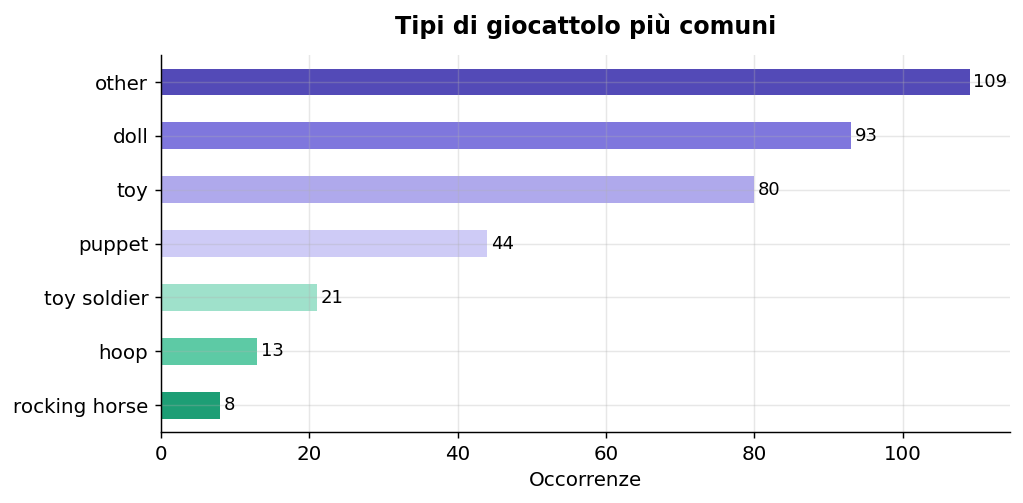

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#534AB7', '#7F77DD', '#AFA9EC', '#CECBF6', '#9FE1CB', '#5DCAA5', '#1D9E75']
toy_counts.plot.barh(ax=ax, color=colors[:len(toy_counts)], edgecolor='none')

ax.invert_yaxis()
ax.set_xlabel('Occorrenze')
ax.set_ylabel('')
ax.set_title('Tipi di giocattolo più comuni', fontweight='bold', pad=12)

for bar, val in zip(ax.patches, toy_counts):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('toy_frequenza.png', bbox_inches='tight')
plt.show()

## 3. Distribuzione per genere dei personaggi

In [13]:
gender_pivot = (
    df.groupby(['toy', 'gender'])
    .size()
    .unstack(fill_value=0)
    .reindex(toy_counts.index)  # ordina per frequenza totale
)
# riordina le colonne per leggibilità
col_order = [c for c in ['Female', 'Male', 'Both', 'Unspecified'] if c in gender_pivot.columns]
gender_pivot = gender_pivot[col_order]
print(gender_pivot)

gender         Female  Male  Both  Unspecified
toy                                           
other              18    21    55           15
doll               42     2    44            5
toy                14    18    37           11
puppet              9    10    14           11
toy soldier         2     9     6            4
hoop                2     2     8            1
rocking horse       2     2     4            0


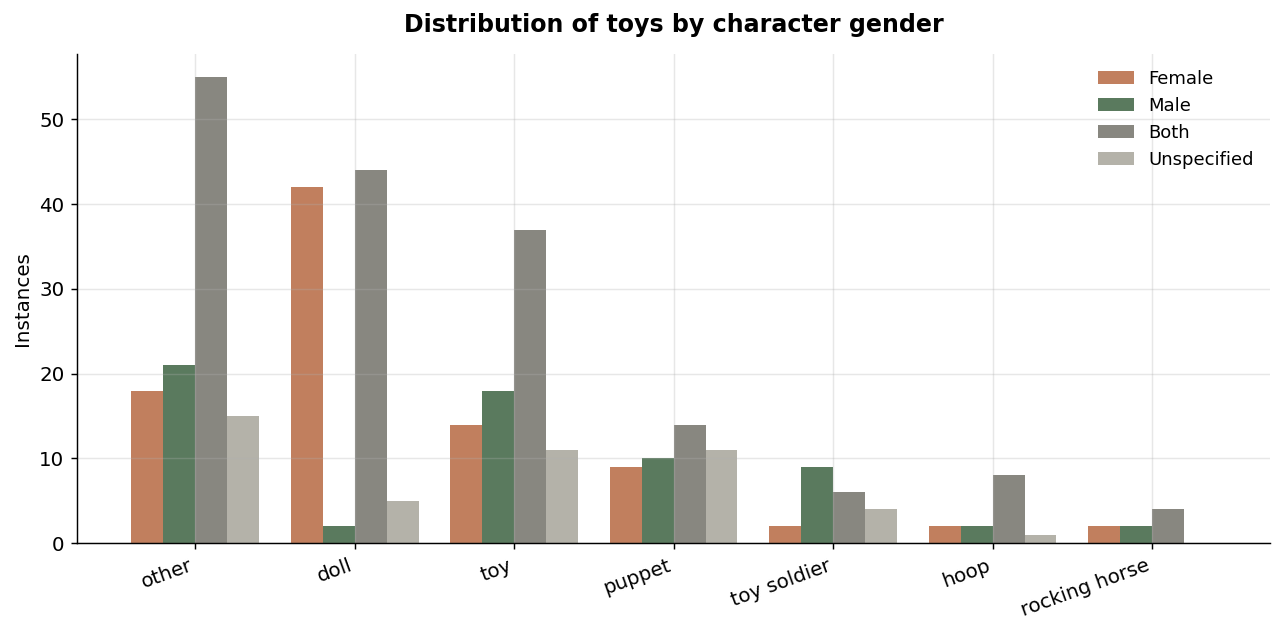

In [16]:
GENDER_COLORS = {
    'Female':       '#c17f5e',
    'Male':        '#5a7a5e',
    'Both':           '#888780',
    'Unspecified': '#B4B2A9',
}

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(gender_pivot))
n_groups = len(gender_pivot.columns)
width = 0.8 / n_groups

for i, col in enumerate(gender_pivot.columns):
    offset = (i - n_groups / 2 + 0.5) * width
    bars = ax.bar(x + offset, gender_pivot[col], width=width,
                  label=col, color=GENDER_COLORS.get(col, '#ccc'),
                  edgecolor='none', linewidth=0)

ax.set_xticks(x)
ax.set_xticklabels(gender_pivot.index, rotation=20, ha='right')
ax.set_ylabel('Instances')
ax.set_title('Distribution of toys by character gender', fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('toy_per_genere.png', bbox_inches='tight')
plt.show()

## 4. Distribuzione per decennio di pubblicazione

In [17]:
decade_pivot = (
    df.dropna(subset=['decade'])
    .groupby(['decade', 'toy'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
# ordina le colonne per frequenza totale
decade_pivot = decade_pivot[toy_counts.index.intersection(decade_pivot.columns)]
print(decade_pivot)

toy     other  doll  toy  puppet  toy soldier  hoop  rocking horse
decade                                                            
1840s       5    14    7      23            9     0              1
1860s      23     9   15       6            2     1              2
1870s      14    14   13       3            2     2              1
1880s      31    20   19       3            4     4              2
1890s      23    23   13       6            4     3              1
1900s       5     6    6       2            0     3              1
1910s       0     2    5       0            0     0              0
1920s       8     5    2       1            0     0              0


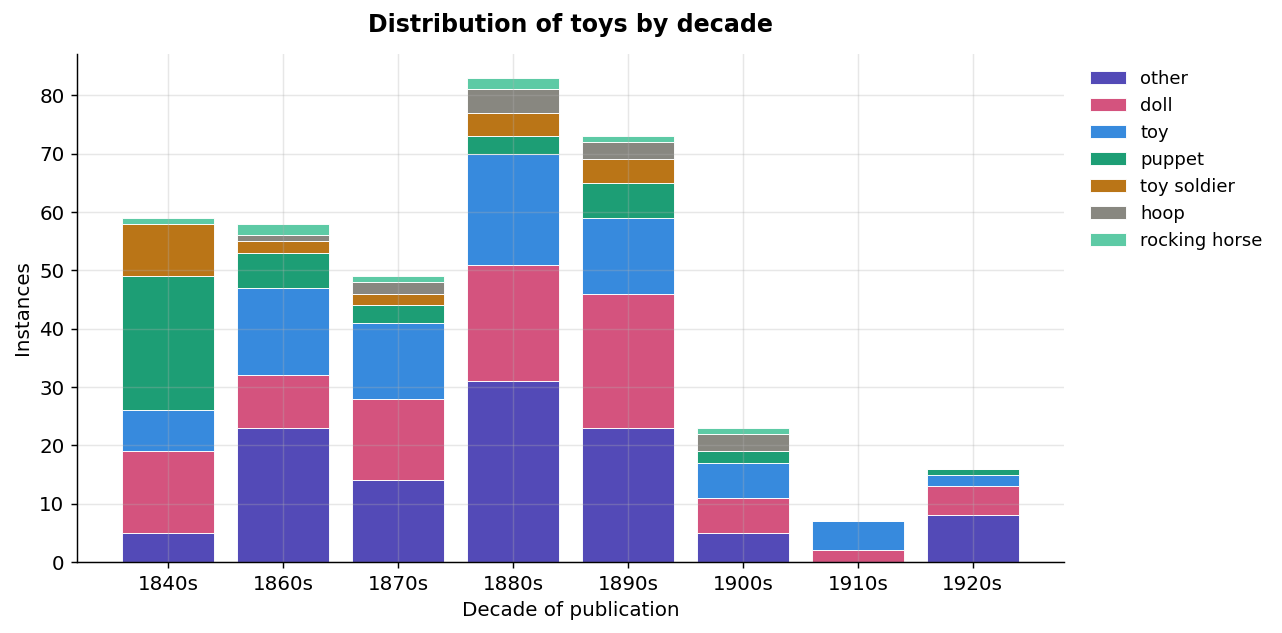

In [19]:
TOY_COLORS = {
    'other':         '#534AB7',
    'doll':          '#D4537E',
    'toy':           '#378ADD',
    'puppet':        '#1D9E75',
    'toy soldier':   '#BA7517',
    'hoop':          '#888780',
    'rocking horse': '#5DCAA5',
}

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(decade_pivot))
for col in decade_pivot.columns:
    vals = decade_pivot[col].values
    ax.bar(decade_pivot.index, vals, bottom=bottom,
           label=col, color=TOY_COLORS.get(col, '#ccc'),
           edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xlabel('Decade of publication')
ax.set_ylabel('Instances')
ax.set_title('Distribution of toys by decade', fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('toy_per_decennio.png', bbox_inches='tight')
plt.show()

## 5. Riepilogo statistico

In [20]:
total_illustrations = len(data)
with_toys = df[['subfolder','file_name']].drop_duplicates().shape[0]

print(f"Illustrazioni totali:              {total_illustrations}")
print(f"Con almeno un giocattolo:          {with_toys} ({with_toys/total_illustrations*100:.1f}%)")
print(f"\nTipo più comune:                   {toy_counts.idxmax()} ({toy_counts.max()} occorrenze)")
print(f"Decennio con più giocattoli:       {decade_pivot.sum(axis=1).idxmax()}")

print("\n── Bambola per genere ──")
print(gender_pivot.loc['doll'] if 'doll' in gender_pivot.index else 'n/d')

Illustrazioni totali:              4332
Con almeno un giocattolo:          280 (6.5%)

Tipo più comune:                   other (109 occorrenze)
Decennio con più giocattoli:       1880s

── Bambola per genere ──
gender
Female         42
Male            2
Both           44
Unspecified     5
Name: doll, dtype: int64


## 5. Libro con più occorrenze per tipo di giocattolo

In [21]:
def subfolder_to_title(subfolder: str) -> str:
    """Converte il nome della sottocartella in un titolo leggibile.
    Es. '1880_L_Oncle_Boni' → "L'Oncle Boni (1880)"
    """
    m = re.match(r'^(\d{4})_(.*)', subfolder)
    if not m:
        return subfolder
    year, rest = m.group(1), m.group(2)
    title = rest.replace('_', ' ').strip()
    return f"{title} ({year})"


# Conta le occorrenze di ogni (toy, subfolder)
book_toy = (
    df.groupby(['toy', 'subfolder'])
    .size()
    .rename('count')
    .reset_index()
)

# Per ogni tipo di giocattolo, prendi il libro con il conteggio massimo
# (in caso di parità vengono restituiti tutti i libri a pari merito)
top_books = (
    book_toy
    .loc[book_toy.groupby('toy')['count'].transform('max') == book_toy['count']]
    .sort_values(['toy', 'subfolder'])
    .copy()
)

top_books['titolo'] = top_books['subfolder'].apply(subfolder_to_title)

# Raggruppa i titoli a pari merito in un'unica riga per toy
result = (
    top_books
    .groupby('toy')
    .apply(lambda g: pd.Series({
        'occorrenze': g['count'].iloc[0],
        'libro_top': ' / '.join(g['titolo']),
    }))
    .reset_index()
    .sort_values('occorrenze', ascending=False)
)

print(result.to_string(index=False))

          toy  occorrenze                                                                                                                                                                                                                                 libro_top
         doll          13                                                                                                                                                                                                       Histoire d'un casse-noisette (1845)
       puppet          13                                                                                                                                                                                                         Monsieur le Vent et Madame (1846)
  toy soldier           9                                                                                                                                                                                                   

/var/folders/hh/ypps8hc950qcwq52q102337r0000gn/T/ipykernel_5880/1062444297.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


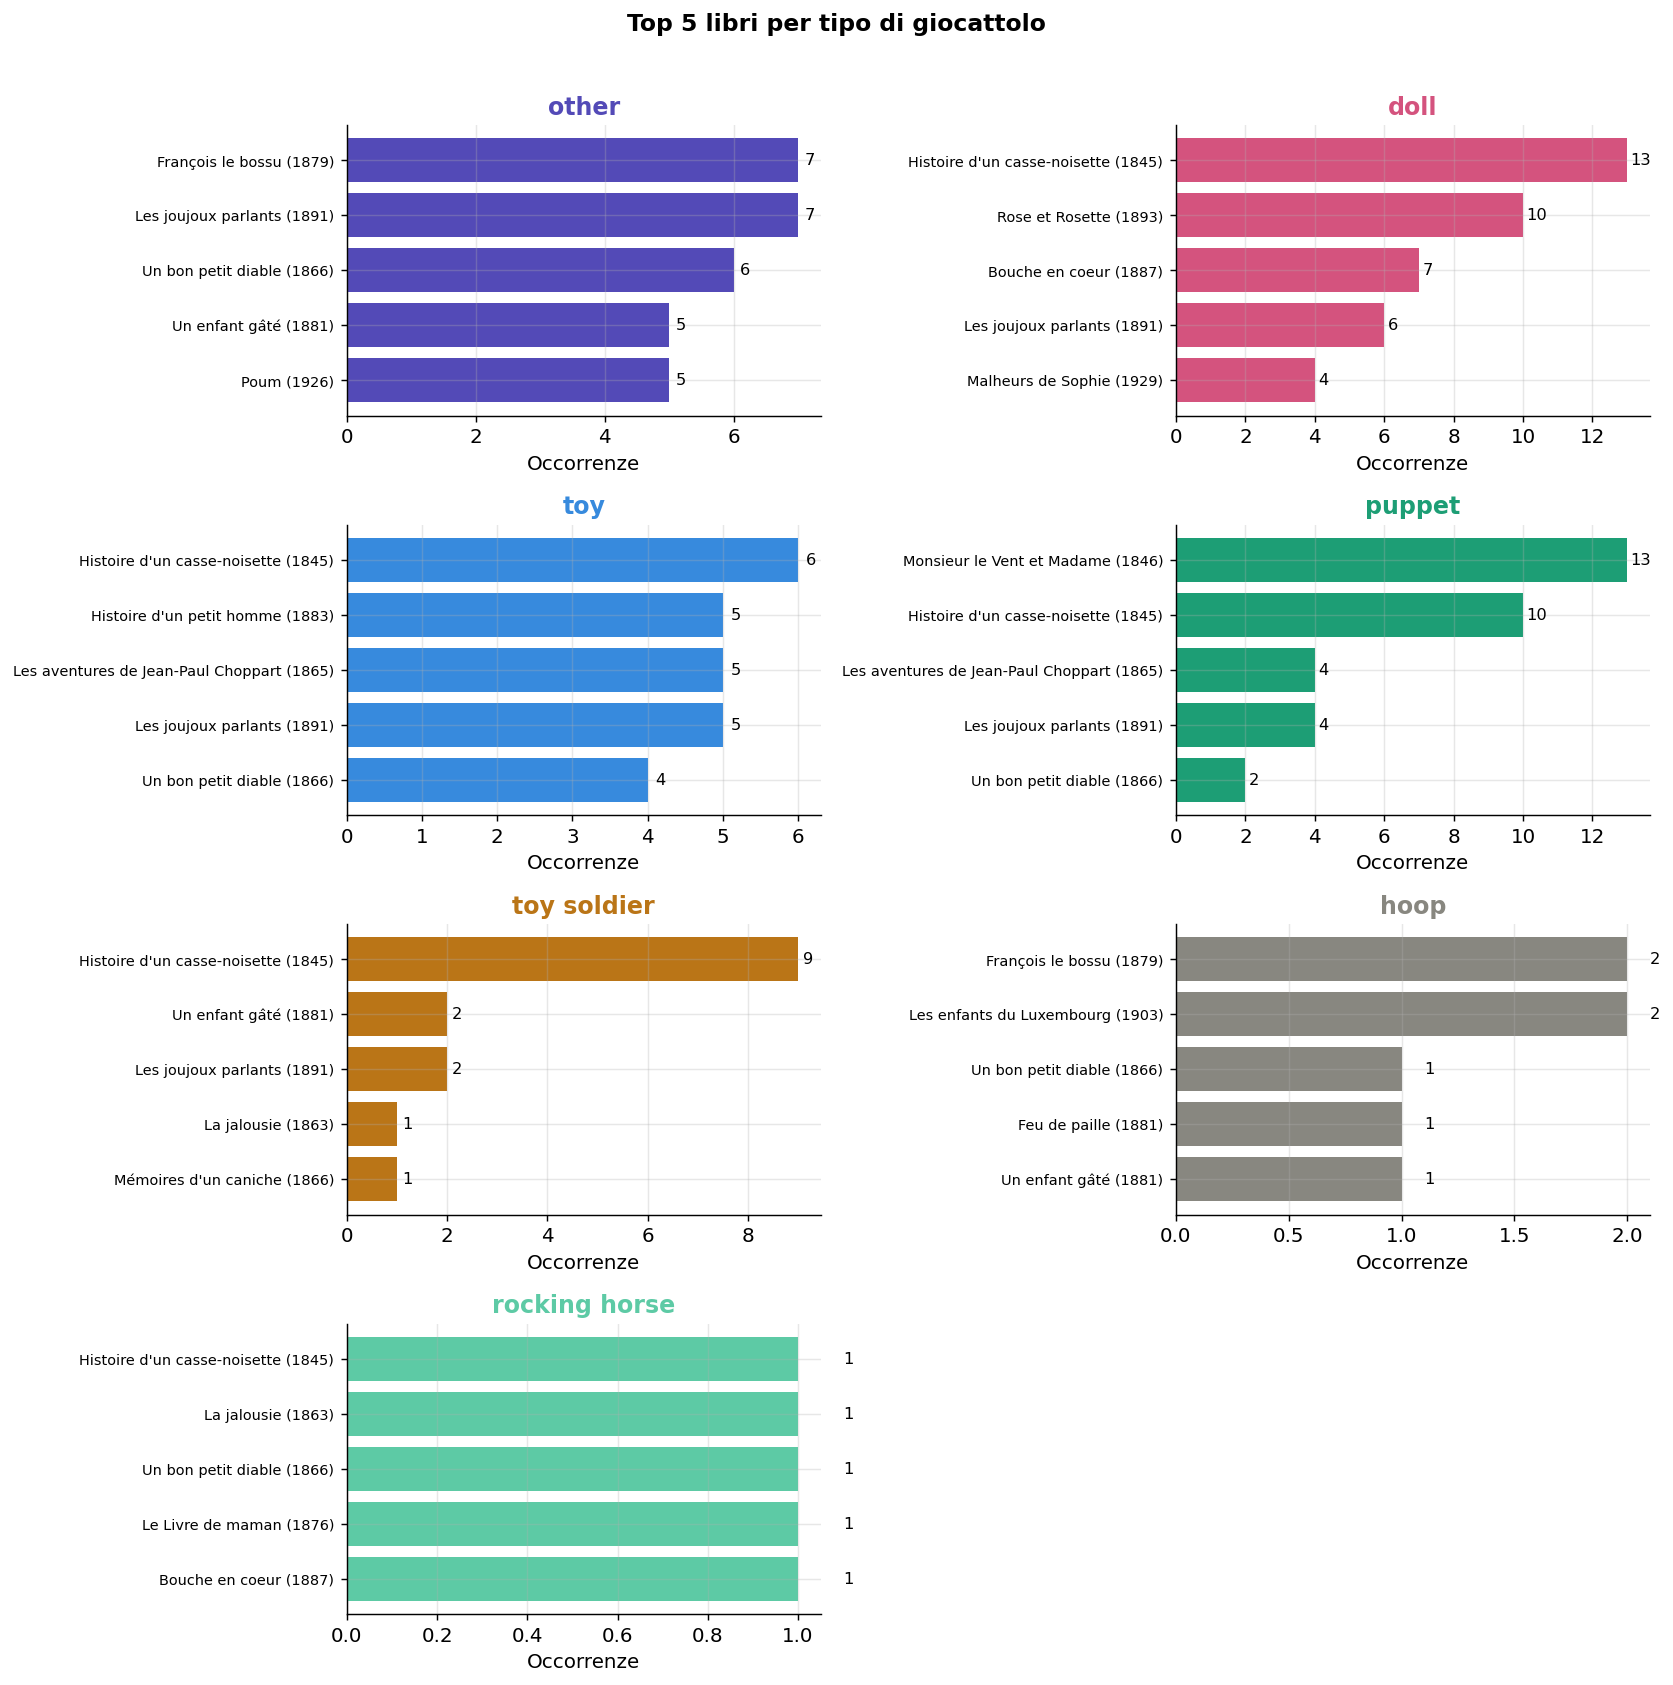

In [22]:
# Visualizzazione: un pannello per tipo di giocattolo con i top-5 libri
top_n = 5
toy_types = toy_counts.index.tolist()  # ordinati per frequenza globale

ncols = 2
nrows = -(-len(toy_types) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 3.2))
axes = axes.flatten()

for ax, toy in zip(axes, toy_types):
    sub = (
        book_toy[book_toy['toy'] == toy]
        .sort_values('count', ascending=False)
        .head(top_n)
        .copy()
    )
    sub['titolo'] = sub['subfolder'].apply(subfolder_to_title)

    color = TOY_COLORS.get(toy, '#888')
    bars = ax.barh(sub['titolo'][::-1], sub['count'][::-1],
                   color=color, edgecolor='none')

    for bar, val in zip(bars, sub['count'][::-1]):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)

    ax.set_title(toy, fontweight='bold', color=color, pad=6)
    ax.set_xlabel('Occorrenze')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Nascondi pannelli vuoti se il numero di toy è dispari
for ax in axes[len(toy_types):]:
    ax.set_visible(False)

fig.suptitle(f'Top {top_n} libri per tipo di giocattolo', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('toy_per_libro.png', bbox_inches='tight')
plt.show()